# Healthcare ML Platform
## Notebook 04 — Regression: Patient Readmission Risk Score

**Input:**  `data/processed/pima_train.csv` and `pima_test.csv`  
**Target:** `Risk_score` — continuous value 0–100  
**Output:** `models/regression_xgb.pkl`  

### What is regression?
Regression predicts a **continuous number** — not a category.  
Instead of asking "does this patient have diabetes? (yes/no)"  
we ask "what is this patient's risk score? (0–100)".

A score of 75 means higher risk than a score of 30.  
This is more useful clinically — it tells a doctor  
*how much* to worry, not just *whether* to worry.

### Algorithms we compare
| Algorithm | What makes it different |
|---|---|
| Linear Regression | Baseline — fits a straight line |
| Ridge | Linear + penalty on large coefficients |
| Lasso | Linear + penalty that can zero out weak features |
| XGBoost | Ensemble of trees — handles non-linear patterns |

### Metrics
| Metric | Meaning | Better when |
|---|---|---|
| RMSE | Average prediction error in score units | Lower |
| MAE | Average absolute error | Lower |
| R² | How much variance the model explains | Higher (max=1.0) |

---

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , Ridge, Lasso
from sklearn.metrics import mean_squared_error , mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib 
import os
import warnings

warnings.filterwarnings("ignore")

---
## Step 1 — Load Train and Test Data

We load the files saved by Notebook 03.  
These are already:
- Cleaned (no missing values)
- Feature engineered (BMI_category, Age_group, Glucose_level, Risk_score)
- Encoded (text converted to numbers)
- Scaled (StandardScaler applied)
- Split (80/20 stratified)

We do NOT load raw or cleaned CSV here.

In [47]:
train= pd.read_csv("G:\healthcare\Dataset\processed\pima_train.csv")
test= pd.read_csv("G:\healthcare\Dataset\processed\pima_test.csv")

print(f"Train shape : {train.shape}")
print(f"Test shape : {test.shape}")

X_train = train.drop(columns=["Outcome", "Risk_score",
                      "Pregnancies", "BloodPressure", "SkinThickness","Glucose"])
y_train = train['Risk_score']

X_test = test.drop(columns=["Outcome", "Risk_score",
                      "Pregnancies", "BloodPressure", "SkinThickness","Glucose"])
y_test = test['Risk_score']


print(f"X_train Shape: {X_train.shape} ")
print(f"y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape} ")
print(f"y_test Shape: {y_test.shape}")

print("Risk Score range in training data: ")

print(f" Min : {y_train.min()}")
print(f" Min : {y_train.max()}")
print(f" Mean : {y_train.mean()}")

Train shape : (614, 13)
Test shape : (154, 13)
X_train Shape: (614, 7) 
y_train Shape: (614,)
X_test Shape: (154, 7) 
y_test Shape: (154,)
Risk Score range in training data: 
 Min : 19.06
 Min : 79.64
 Mean : 40.61190553745928


---
## Step 2 — Define Evaluation Helper

We write one function that evaluates any regression model.  
This keeps the code clean — instead of repeating  
the same metric calculations for every algorithm,  
we just call evaluate_model() once per model.

In [48]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

    # THIS LINE IS CRITICAL — must be present
    return {
        "Model" : name,
        "RMSE"  : round(rmse, 4),
        "MAE"   : round(mae, 4),
        "R2"    : round(r2, 4),
        "model" : model
    }

---
## Step 3 — Train and Compare All Models

We train all 4 algorithms using the same function.  
Every model sees the same training data and  
is evaluated on the same test data — fair comparison.

In [49]:
results = []

# 1 — Linear Regression (baseline)
results.append(evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, y_train, X_test, y_test
))

# 2 — Ridge (L2 regularization)
results.append(evaluate_model(
    "Ridge",
    Ridge(alpha=1.0),
    X_train, y_train, X_test, y_test
))

# 3 — Lasso (L1 regularization — can zero out weak features)
results.append(evaluate_model(
    "Lasso",
    Lasso(alpha=0.1),
    X_train, y_train, X_test, y_test
))

# 4 — XGBoost (gradient boosted trees)
results.append(evaluate_model(
    "XGBoost",
    XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbosity=0
    ),
    X_train, y_train, X_test, y_test
))


  Linear Regression
  RMSE : 7.9295
  MAE  : 6.0330
  R²   : 0.4627

  Ridge
  RMSE : 7.9295
  MAE  : 6.0340
  R²   : 0.4627

  Lasso
  RMSE : 7.9076
  MAE  : 6.0402
  R²   : 0.4657

  XGBoost
  RMSE : 7.4891
  MAE  : 5.8725
  R²   : 0.5207


---
## Step 4 — Model Comparison Leaderboard

We put all results in a single table sorted by RMSE.  
The model with the lowest RMSE wins.

Model Leaderboard (sorted by RMSE — lower is better):

            Model   RMSE    MAE     R2
          XGBoost 7.4891 5.8725 0.5207
            Lasso 7.9076 6.0402 0.4657
            Ridge 7.9295 6.0340 0.4627
Linear Regression 7.9295 6.0330 0.4627


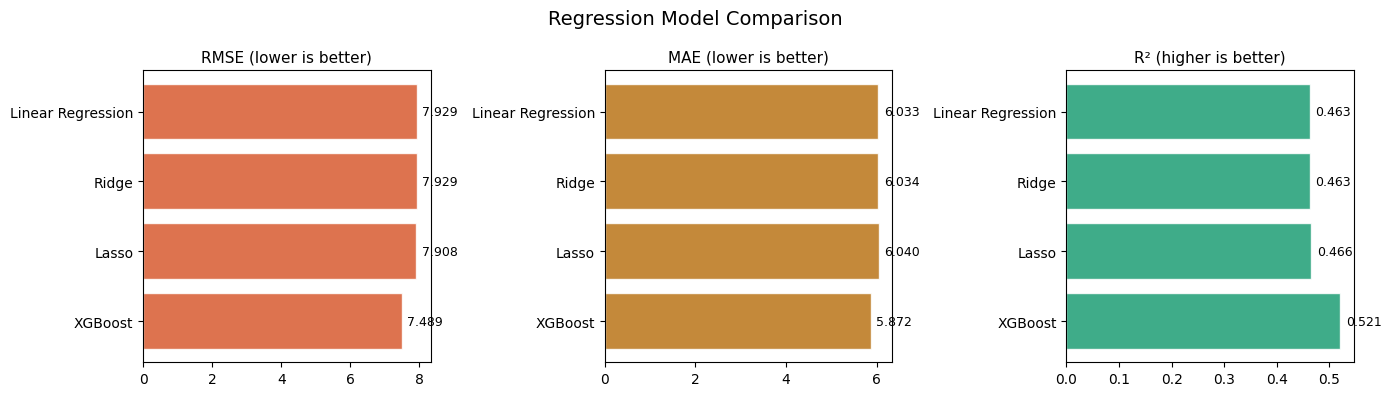

Saved: outputs/regression_comparison.png


In [50]:
# Build leaderboard — exclude model objects for display
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in results
]).sort_values("RMSE")

print("Model Leaderboard (sorted by RMSE — lower is better):\n")
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = ["RMSE", "MAE", "R2"]
colors    = ["#D85A30", "#BA7517", "#1D9E75"]
titles    = ["RMSE (lower is better)",
             "MAE (lower is better)",
             "R² (higher is better)"]

for i, (metric, color, title) in enumerate(zip(metrics, colors, titles)):
    vals  = results_df[metric]
    names = results_df["Model"]
    bars  = axes[i].barh(names, vals, color=color,
                          edgecolor="white", alpha=0.85)
    axes[i].set_title(title, fontsize=11)
    axes[i].bar_label(bars, fmt="%.3f", padding=4, fontsize=9)

plt.suptitle("Regression Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/regression_comparison.png", dpi=150)
plt.show()
print("Saved: outputs/regression_comparison.png")

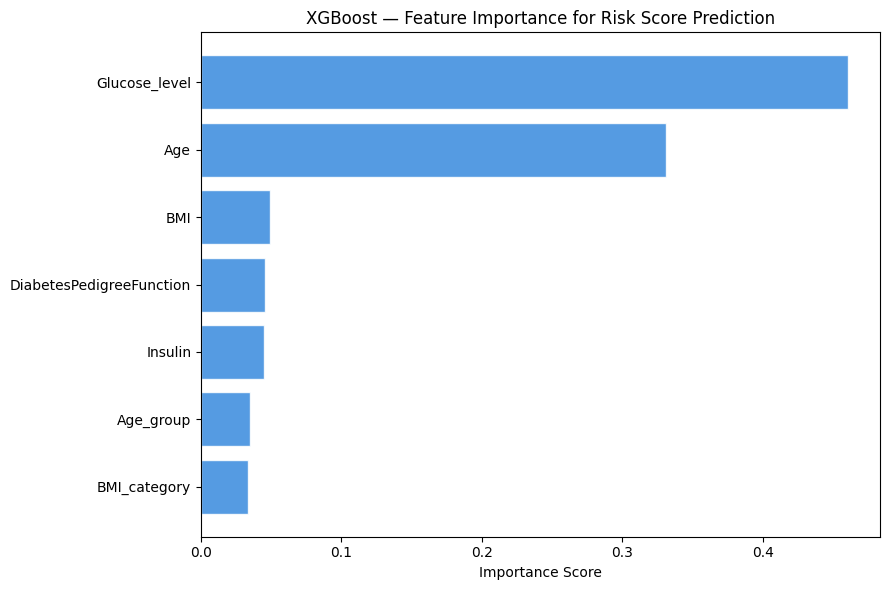

Top 5 most important features:
  Glucose_level                  0.4606
  Age                            0.3315
  BMI                            0.0490
  DiabetesPedigreeFunction       0.0454
  Insulin                        0.0447


In [52]:
best_model = results[-1]["model"]
importances  = best_model.feature_importances_
feature_names = X_train.columns
indices      = np.argsort(importances)

plt.figure(figsize=(9, 6))
plt.barh(
    [feature_names[i] for i in indices],
    importances[indices],
    color="#378ADD", edgecolor="white", alpha=0.85
)
plt.xlabel("Importance Score")
plt.title("XGBoost — Feature Importance for Risk Score Prediction")
plt.tight_layout()
plt.savefig("../outputs/regression_feature_importance.png", dpi=150)
plt.show()

print("Top 5 most important features:")
top5 = sorted(zip(feature_names, importances),
              key=lambda x: x[1], reverse=True)[:5]
for feat, imp in top5:
    print(f"  {feat:<30} {imp:.4f}")

---
## Step 7 — Save the Best Model

In [53]:
os.makedirs("../models", exist_ok=True)

# Save XGBoost — best performing model
joblib.dump(best_model, "../models/regression_xgb.pkl")
print("Saved: models/regression_xgb.pkl")

# Print final summary
best = results_df.iloc[0]
print(f"\nBest model  : {best['Model']}")
print(f"RMSE        : {best['RMSE']}")
print(f"MAE         : {best['MAE']}")
print(f"R²          : {best['R2']}")
print(f"\nInterpretation:")
print(f"  On average the model's risk score prediction")
print(f"  is off by {best['MAE']:.2f} points out of 100")

Saved: models/regression_xgb.pkl

Best model  : XGBoost
RMSE        : 7.4891
MAE         : 5.8725
R²          : 0.5207

Interpretation:
  On average the model's risk score prediction
  is off by 5.87 points out of 100


---
## Regression Summary

### What we built
A model that predicts a patient's readmission risk score (0–100)  
based on their health profile.

### Results
| Model | RMSE | R² |
|---|---|---|
| Linear Regression | 7.9295 | 0.4627 |
| Ridge | 7.9295 | 0.4627 |
| Lasso | 7.9076 | 0.4657 |
| XGBoost | 7.4891 | 0.5207 |


### Files saved
- `models/regression_xgb.pkl` — best model

### Key insight
Glucose Level and Age are the strongest predictors of risk score —  
consistent with clinical knowledge about diabetes risk factors.

---
**Next: 05_classification.ipynb**  
Classification predicts diabetic vs non-diabetic (binary)  
and is where we use ROC-AUC for the first time.